# Pseudo YOLO Annotations

Goal: use existing image folder labels plus pretrained YOLO boxes to create a first YOLO-format training dataset.

This is weak supervision. It is useful for bootstrapping, but the generated boxes should be reviewed before being treated as ground truth.


In [23]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
project_root


WindowsPath('d:/Green Waste/V1_GreenWaste')

## 1) Generate a pilot pseudo-labelled dataset

This small pilot is capped per class so it runs quickly. Increase `--max-per-class` once the boxes look sensible.

`--box-padding` expands accepted YOLO boxes before saving labels. This helps when pretrained YOLO detects only the most recognisable part of a product image rather than the whole waste item.

`--foreground-fallback` is useful for clean IKEA-style product images on white backgrounds. YOLO still confirms the class, but if the box is too partial, the saved box is estimated from the whole non-white foreground object.


In [24]:
import os
import subprocess
import sys

env = os.environ.copy()
env['PYTHONPATH'] = str(project_root / 'src')

cmd = [
    sys.executable,
    '-m',
    'greenwaste.pseudo_yolo_annotations',
    '--input-dir',
    str(project_root / 'data' / 'raw' / 'realsense' / 'labelled'),
    '--output-dir',
    str(project_root / 'data' / 'processed' / 'yolo_pseudo_pilot'),
    '--weights',
    str(project_root / 'models' / 'yolo11s.pt'),
    '--confidence',
    '0.25',
    '--image-size',
    '960',
    '--box-padding',
    '0.35',
    '--foreground-fallback',
    '--prefer-foreground-box',
    '--foreground-threshold',
    '252',
    '--foreground-padding',
    '0.08',
    '--min-box-area-ratio',
    '0.45',
    '--max-per-class',
    '10',
]

result = subprocess.run(cmd, cwd=project_root, env=env, text=True, capture_output=True)
print(result.stdout)
print(result.stderr)
result.check_returncode()


Accepted pseudo annotations: 15
Output directory: d:\Green Waste\V1_GreenWaste\data\processed\yolo_pseudo_pilot




## 2) Inspect class coverage


In [25]:
import pandas as pd

pseudo_dir = project_root / 'data' / 'processed' / 'yolo_pseudo_pilot'
summary_path = pseudo_dir / 'pseudo_annotations.csv'
annotations = pd.read_csv(summary_path)

annotations.groupby(['broad_label', 'yolo_class']).size().reset_index(name='count')


,broad_label,yolo_class,count
0,beds_mattresses,bed,6
1,chair_seating,bench,3
2,chair_seating,chair,1
3,sofa,couch,5


In [26]:
annotations[['broad_label', 'yolo_class', 'confidence']].groupby('broad_label').agg(
    count=('confidence', 'count'),
    mean_confidence=('confidence', 'mean'),
    min_confidence=('confidence', 'min'),
    max_confidence=('confidence', 'max'),
)


,count,mean_confidence,min_confidence,max_confidence
broad_label,,,,
beds_mattresses,6,0.343574,0.255818,0.392801
chair_seating,4,0.552167,0.350716,0.867645
sofa,5,0.519916,0.359724,0.580813


## 3) Preview generated boxes


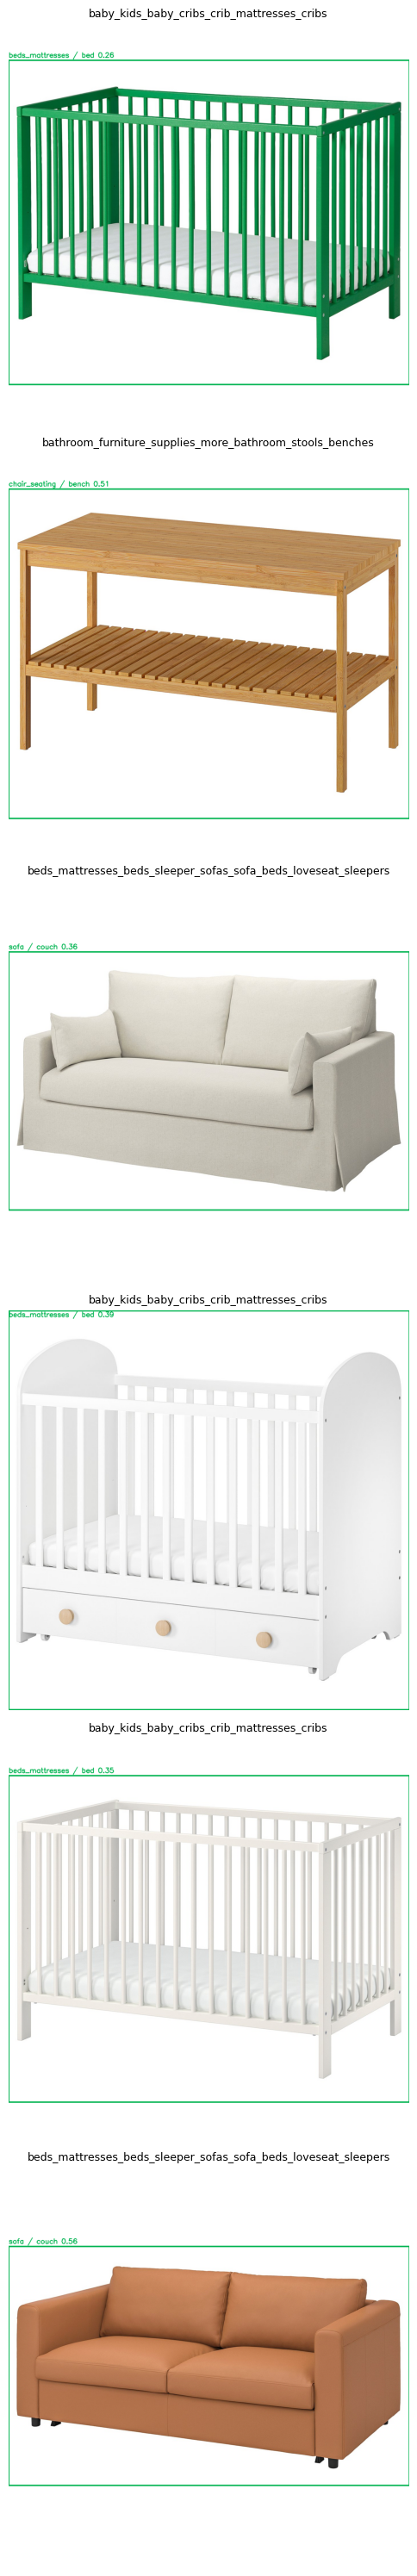

In [27]:
import cv2
import matplotlib.pyplot as plt

def draw_annotation(row):
    image_path = Path(row.output_image_path)
    if not image_path.is_absolute():
        image_path = project_root / image_path
    image = cv2.imread(str(image_path))
    if image is None:
        raise RuntimeError(f'Could not load {image_path}')
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    x1, y1, x2, y2 = int(row.x1), int(row.y1), int(row.x2), int(row.y2)
    label = f'{row.broad_label} / {row.yolo_class} {row.confidence:.2f}'
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 180, 80), 3)
    cv2.putText(image, label, (x1, max(y1 - 10, 25)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 180, 80), 2)
    return image

sample = annotations.sample(min(6, len(annotations)), random_state=42)
fig, axes = plt.subplots(len(sample), 1, figsize=(8, 5 * len(sample)))
if len(sample) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample.iterrows()):
    ax.imshow(draw_annotation(row))
    ax.set_title(row.raw_label, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 4) Train a custom YOLO model later

Once the pseudo boxes look good enough, generate a larger dataset and train from its `data.yaml`.


In [ ]:
data_yaml = pseudo_dir / 'data.yaml'
print(data_yaml)
print(data_yaml.read_text())


d:\Green Waste\V1_GreenWaste\data\processed\yolo_pseudo_pilot\data.yaml
path: d:/Green Waste/V1_GreenWaste/data/processed/yolo_pseudo_pilot
train: images/train
val: images/val
names:
  0: beds_mattresses
  1: chair_seating
  2: sofa
  3: storage
  4: tables_desks

